In [2]:
!pip install equinox
!pip install jax
!pip install optax
!pip install diffrax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 4.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.2/193.2 kB 5.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.4/97.4 kB 8.9 MB/s eta 0:00:00


In [21]:
import os
import sys
import time
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
import optax
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt

# ----------------------------
# Config
# ----------------------------
LABELS_FILE = Path("/kaggle/input/sepsis/B/labels.csv")
TS_DIR = Path("/kaggle/input/sepsis/B/time_series")

N_PATIENTS = 20000      # full dataset
RANDOM_SEED = 0

# Model capacity
HIDDEN_DIM = 128        # bigger hidden state → captures more temporal info
ODE_WIDTH = 256         # wider MLP inside ODEFunc → more expressive dynamics
ODE_DEPTH = 3           # slightly deeper → more nonlinearity

# Training
LEARNING_RATE = 5e-4    # slightly lower → more stable for bigger model
EPOCHS = 50             # longer training
PATIENCE = 8            # allow more epochs for early stopping

# Missing data
IMPUTE_VARIANT = "grud"  # best for irregular and sparse time series


# Feature names (PhysioNet-like)
VITAL_SIGNS = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2']
LAB_VALUES = [
    'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
    'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
    'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
    'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
    'Fibrinogen', 'Platelets'
]
STATIC_COLS = ['Age', 'Gender']
FEATURE_COLS = VITAL_SIGNS + LAB_VALUES
INPUT_DIM = len(FEATURE_COLS)

# JAX config
np.random.seed(RANDOM_SEED)
jax.config.update("jax_enable_x64", False)

# ----------------------------
# Helpers: robust CSV reading
# ----------------------------
def robust_read_csv(path):
    seps = [',', '|', ';', '\t']
    for sep in seps:
        try:
            df = pd.read_csv(path, sep=sep, engine='c')
            header_present = any(not str(c).isdigit() for c in df.columns)
            return df, header_present
        except Exception:
            continue
    # try without header
    for sep in seps:
        try:
            df = pd.read_csv(path, sep=sep, header=None, engine='c')
            return df, False
        except Exception:
            continue
    # final fallback
    df = pd.read_csv(path, header=None, engine='c')
    return df, False

# ----------------------------
# 1) Load labels robustly
# ----------------------------
if not LABELS_FILE.exists():
    raise FileNotFoundError(f"Labels file not found: {LABELS_FILE}")

labels_df = None
for sep in [',', '|', ';', '\t']:
    try:
        tmp = pd.read_csv(LABELS_FILE, sep=sep, engine='c')
        if tmp.shape[1] >= 2:
            labels_df = tmp.copy()
            break
    except Exception:
        continue
if labels_df is None:
    labels_df = pd.read_csv(LABELS_FILE, engine='c')

labels_df = labels_df.iloc[:, :2].copy()
labels_df.columns = ['patient', 'label']
labels_df['patient'] = labels_df['patient'].astype(str).str.strip()
labels_df['label'] = pd.to_numeric(labels_df['label'], errors='coerce').fillna(0).astype(int)

labels_dict = {}
for pid, lab in zip(labels_df['patient'], labels_df['label']):
    labels_dict[pid] = int(lab)
    if pid.startswith('p'):
        labels_dict[pid[1:]] = int(lab)
    else:
        labels_dict['p' + pid] = int(lab)

# ----------------------------
# 2) Find patient files (limit to N_PATIENTS)
# ----------------------------
if not TS_DIR.exists():
    raise FileNotFoundError(f"Time series directory not found: {TS_DIR}")

patient_files = sorted(list(TS_DIR.glob("p*.csv")))
if len(patient_files) == 0:
    patient_files = sorted(list(TS_DIR.glob("*.csv")))
if len(patient_files) == 0:
    raise ValueError("No time-series files found.")

patient_files = patient_files[:N_PATIENTS]

# ----------------------------
# 3) Parse patient time-series to arrays
# ----------------------------
def parse_patient_df(raw_df, header_present):
    df = raw_df.copy()
    cols = list(df.columns.astype(str))
    cols_lower = [c.lower() for c in cols]
    df_num = df.apply(lambda s: pd.to_numeric(s, errors='coerce'))

    # Try to select FEATURE_COLS by name
    selected = []
    for fname in FEATURE_COLS:
        if fname.lower() in cols_lower:
            selected.append(cols[cols_lower.index(fname.lower())])
    if len(selected) == INPUT_DIM:
        X_df = df_num[selected]
    else:
        numeric_cols = [c for c in df_num.columns if df_num[c].notna().any()]
        if len(numeric_cols) >= INPUT_DIM:
            X_df = df_num[numeric_cols[:INPUT_DIM]]
        else:
            tmp = pd.DataFrame(np.nan, index=df_num.index, columns=[f'f{i}' for i in range(INPUT_DIM)])
            for i, c in enumerate(numeric_cols):
                tmp.iloc[:, i] = df_num[c]
            X_df = tmp

    X = X_df.values.astype(np.float32)
    mask = (~np.isnan(X)).astype(np.float32)
    X_filled = np.nan_to_num(X, nan=0.0).astype(np.float32)

    seq_len = X_filled.shape[0]
    if seq_len == 0:
        return None
    if seq_len == 1:
        time = np.array([0.0], dtype=np.float32)
    else:
        time = np.arange(seq_len, dtype=np.float32)
        time = time / (seq_len - 1 + 1e-8)

    static_vals = []
    for sname in STATIC_COLS:
        if sname.lower() in cols_lower:
            idx = cols_lower.index(sname.lower())
            col = df_num.iloc[:, idx]
            v = col.dropna().iloc[0] if col.dropna().shape[0] > 0 else 0.0
            static_vals.append(float(v))
        else:
            static_vals.append(0.0)
    static = np.array(static_vals, dtype=np.float32)

    return {'X': X_filled, 'mask': mask, 'time': time, 'static': static}

def load_patient(fp):
    try:
        raw_df, header_present = robust_read_csv(fp)
        parsed = parse_patient_df(raw_df, header_present)
        if parsed is None:
            return None
        pid = fp.stem
        label = labels_dict.get(pid, None)
        if label is None:
            label = labels_dict.get(pid[1:], None) if pid.startswith('p') else labels_dict.get('p' + pid, None)
        if label is None:
            return None
        parsed['patient_id'] = pid
        parsed['label'] = int(label)
        if parsed['X'].shape[0] < 2:
            return None
        return parsed
    except Exception as e:
        print(f"Warning: failed to parse {fp.name}: {e}", file=sys.stderr)
        return None

all_patients = []
for fp in patient_files:
    p = load_patient(fp)
    if p is not None:
        all_patients.append(p)

print(f"Loaded {len(all_patients)} patients (requested {len(patient_files)})")
if len(all_patients) < 4:
    raise ValueError("Too few patients parsed. Check files/format.")

# ----------------------------
# 4) Per-feature stats for normalization and GRU-D global means
# ----------------------------
col_values = [[] for _ in range(INPUT_DIM)]
for p in all_patients:
    X = p['X']; mask = p['mask']
    for c in range(INPUT_DIM):
        vals = X[mask[:, c] == 1, c]
        if vals.size > 0:
            col_values[c].append(vals)
global_means = np.zeros(INPUT_DIM, dtype=np.float32)
for c in range(INPUT_DIM):
    if len(col_values[c]) == 0:
        global_means[c] = 0.0
    else:
        global_means[c] = float(np.concatenate(col_values[c]).mean())

means = global_means.copy()
stds = np.ones(INPUT_DIM, dtype=np.float32)
for c in range(INPUT_DIM):
    if len(col_values[c]) == 0:
        stds[c] = 1.0
    else:
        arr = np.concatenate(col_values[c])
        s = np.std(arr)
        stds[c] = float(s) if s > 1e-6 else 1.0

# Normalize observed values, keep zeros at missing positions
for p in all_patients:
    X = p['X']; mask = p['mask']
    Xn = np.zeros_like(X, dtype=np.float32)
    for c in range(INPUT_DIM):
        Xn[:, c] = (X[:, c] - means[c]) / stds[c]
    Xn = Xn * mask
    p['X'] = Xn.astype(np.float32)

global_means_norm = (global_means - means) / stds

# ----------------------------
# 5) Train/Val/Test split
# ----------------------------
np.random.seed(RANDOM_SEED)
np.random.shuffle(all_patients)
n = len(all_patients)
n_train = int(0.7 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val

train_data = all_patients[:n_train]
val_data = all_patients[n_train:n_train + n_val]
test_data = all_patients[n_train + n_val:]

train_pos = sum(p['label'] for p in train_data)
print(f"Split: train {len(train_data)}, val {len(val_data)}, test {len(test_data)} (train_pos={train_pos})")

# ----------------------------
# 6) Model (ODE-RNN) with two possible imputations
# ----------------------------
class ODEFunc(eqx.Module):
    mlp: eqx.nn.MLP
    def __init__(self, hdim, width, depth, key):
        self.mlp = eqx.nn.MLP(in_size=hdim, out_size=hdim, width_size=width, depth=depth,
                              activation=jax.nn.tanh, key=key)
    def __call__(self, t, h, args=None):
        return self.mlp(h)

class ODERNNCell(eqx.Module):
    ode_func: ODEFunc
    gru: eqx.nn.GRUCell
    hdim: int

    def __init__(self, input_dim, hdim, ode_width, ode_depth, key):
        k1, k2 = jax.random.split(key)
        self.ode_func = ODEFunc(hdim, ode_width, ode_depth, k1)
        self.gru = eqx.nn.GRUCell(input_dim, hdim, key=k2)
        self.hdim = hdim

    def __call__(self, h, x, t0, t1):
        t0 = jnp.asarray(t0, dtype=jnp.float32)
        t1 = jnp.asarray(t1, dtype=jnp.float32)

        def solve_ode(_):
            term = diffrax.ODETerm(self.ode_func)
            solver = diffrax.Tsit5()
            sol = diffrax.diffeqsolve(
                term,
                solver,
                t0=t0,
                t1=t1,
                y0=h,
                dt0=None,
                stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-5),
                max_steps=500
            )
            return sol.ys[-1]

        # Use jax.lax.cond to avoid Python branching on tracers
        h_evolved = jax.lax.cond(jnp.allclose(t0, t1), lambda _: h, solve_ode, operand=None)
        # IMPORTANT: GRUCell expects (input, hidden) -> call as gru(x, h)
        h_new = self.gru(x, h_evolved)
        return h_new

class SepsisODERNN(eqx.Module):
    ode_cell: ODERNNCell
    classifier: eqx.nn.MLP
    input_dim: int
    hidden_dim: int
    impute_rnn: eqx.nn.GRUCell = None
    grud_w: jnp.ndarray = None
    grud_b: jnp.ndarray = None
    global_means: jnp.ndarray = None
    variant: str = "impute_rnn"

    def __init__(self, input_dim, hidden_dim, ode_width, ode_depth, key, variant="impute_rnn", global_means=None):
        k1, k2, k3, k4 = jax.random.split(key, 4)
        self.ode_cell = ODERNNCell(input_dim, hidden_dim, ode_width, ode_depth, k1)
        self.classifier = eqx.nn.MLP(in_size=hidden_dim, out_size=1, width_size=hidden_dim, depth=2,
                                     activation=jax.nn.relu, key=k2)
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.variant = variant

        if variant == "impute_rnn":
            # GRUCell(input_size, hidden_size)
            self.impute_rnn = eqx.nn.GRUCell(input_dim * 2, input_dim, key=k3)
        elif variant == "grud":
            init_w = jax.random.normal(k3, (input_dim,)) * 0.1
            init_b = jax.random.normal(k4, (input_dim,)) * 0.1
            self.grud_w = jnp.array(init_w)
            self.grud_b = jnp.array(init_b)
            self.global_means = jnp.array(global_means if global_means is not None else jnp.zeros((input_dim,)), dtype=jnp.float32)
        else:
            raise ValueError("Unknown variant")

    def __call__(self, X, mask, time):
        if self.variant == "impute_rnn":
            return self._call_impute_rnn(X, mask, time)
        else:
            return self._call_grud(X, mask, time)

    def _call_impute_rnn(self, X, mask, time):
        def step(carry, inputs):
            h_imp, h_ode = carry
            x_t, mask_t, t0, t1 = inputs
            impute_input = jnp.concatenate([x_t, mask_t])
            # IMPORTANT: GRUCell expects (input, hidden)
            h_imp = self.impute_rnn(impute_input, h_imp)
            x_imputed = x_t * mask_t + h_imp * (1.0 - mask_t)
            h_ode = self.ode_cell(h_ode, x_imputed, t0, t1)
            return (h_imp, h_ode), h_ode

        h_imp_0 = jnp.zeros(self.input_dim)
        h_ode_0 = jnp.zeros(self.hidden_dim)
        t0 = time
        t1 = jnp.concatenate([time[1:], time[-1:]])
        (_, h_seq) = jax.lax.scan(step, (h_imp_0, h_ode_0), (X, mask, t0, t1))
        h_final = h_seq[-1]
        return self.classifier(h_final).squeeze()

    def _call_grud(self, X, mask, time):
        def step(carry, inputs):
            h_ode, last_obs, last_time = carry
            x_t, mask_t, t0, t1 = inputs
            # delta per feature
            delta = t1 - last_time  # shape (input_dim,)
            delta = jnp.maximum(delta, 0.0)
            w_pos = jax.nn.softplus(self.grud_w)
            b = self.grud_b
            pre = w_pos * delta + b
            gamma = jnp.exp(-jax.nn.relu(pre))
            x_imputed = mask_t * x_t + (1.0 - mask_t) * (gamma * last_obs + (1.0 - gamma) * self.global_means)
            h_ode = self.ode_cell(h_ode, x_imputed, t0, t1)
            last_obs = jnp.where(mask_t == 1.0, x_t, last_obs)
            last_time = jnp.where(mask_t == 1.0, t1, last_time)
            return (h_ode, last_obs, last_time), h_ode

        h_ode_0 = jnp.zeros(self.hidden_dim)
        last_obs_0 = jnp.array(self.global_means, dtype=jnp.float32)
        last_time_0 = jnp.full((self.input_dim,), -1.0, dtype=jnp.float32)
        t0 = time
        t1 = jnp.concatenate([time[1:], time[-1:]])
        (_, h_seq) = jax.lax.scan(step, (h_ode_0, last_obs_0, last_time_0), (X, mask, t0, t1))
        h_final = h_seq[-1]
        return self.classifier(h_final).squeeze()

# ----------------------------
# 7) Initialize model, loss, optimizer
# ----------------------------
key = jax.random.PRNGKey(RANDOM_SEED)
model_key, train_key = jax.random.split(key)
model = SepsisODERNN(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM,
                     ode_width=ODE_WIDTH, ode_depth=ODE_DEPTH,
                     key=model_key, variant=IMPUTE_VARIANT, global_means=global_means_norm)

# ----------------------------
# Safe pos weight for heavy imbalance
# ----------------------------
train_pos = sum(p['label'] for p in train_data)
train_neg = len(train_data) - train_pos
epsilon = 1e-6
pos_weight = float((train_neg + epsilon) / (train_pos + epsilon))

@eqx.filter_jit
def loss_fn(model, X, mask, time, label):
    logit = model(X, mask, time)
    bce = optax.sigmoid_binary_cross_entropy(logit, label)
    weight = 1.0 + (pos_weight - 1.0) * label
    bce = jnp.clip(bce, 0.0, 10.0)
    return jnp.mean(bce * weight)

@eqx.filter_jit
def compute_metrics(model, X, mask, time, label):
    logit = model(X, mask, time)
    prob = jax.nn.sigmoid(logit)
    pred = (prob > 0.5).astype(jnp.float32)
    return {'logit': logit, 'prob': prob, 'pred': pred, 'correct': (pred == label).astype(jnp.float32)}

optimizer = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(LEARNING_RATE))
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

@eqx.filter_jit
def train_step(model, opt_state, X, mask, time, label):
    loss, grads = eqx.filter_value_and_grad(loss_fn)(model, X, mask, time, label)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

# ----------------------------
# 8) Training loop
# ----------------------------
best_val_auroc = 0.0
best_model = model
patience_counter = 0

train_history = {'loss': [], 'auroc': []}
val_history = {'loss': [], 'auroc': []}

for epoch in range(EPOCHS):
    np.random.shuffle(train_data)
    train_losses = []
    train_probs = []
    train_labels = []

    for patient in train_data:
        X = jnp.array(patient['X'])
        mask = jnp.array(patient['mask'])
        time_arr = jnp.array(patient['time'])
        label = jnp.array(float(patient['label']))
        try:
            model, opt_state, loss = train_step(model, opt_state, X, mask, time_arr, label)
            if not jnp.isnan(loss):
                train_losses.append(float(loss))
                m = compute_metrics(model, X, mask, time_arr, label)
                train_probs.append(float(m['prob']))
                train_labels.append(int(patient['label']))
        except Exception as e:
            print(f"Warning: train step failed for {patient['patient_id']}: {e}", file=sys.stderr)
            continue

    # validation
    val_losses = []
    val_probs = []
    val_labels = []
    for patient in val_data:
        X = jnp.array(patient['X'])
        mask = jnp.array(patient['mask'])
        time_arr = jnp.array(patient['time'])
        label = jnp.array(float(patient['label']))
        try:
            loss = loss_fn(model, X, mask, time_arr, label)
            if not jnp.isnan(loss):
                val_losses.append(float(loss))
                m = compute_metrics(model, X, mask, time_arr, label)
                val_probs.append(float(m['prob']))
                val_labels.append(int(patient['label']))
        except Exception as e:
            print(f"Warning: val eval failed for {patient['patient_id']}: {e}", file=sys.stderr)
            continue

    train_loss = np.mean(train_losses) if train_losses else float('inf')
    val_loss = np.mean(val_losses) if val_losses else float('inf')
    train_auroc = roc_auc_score(train_labels, train_probs) if len(set(train_labels)) > 1 else 0.0
    val_auroc = roc_auc_score(val_labels, val_probs) if len(set(val_labels)) > 1 else 0.0

    train_history['loss'].append(train_loss)
    train_history['auroc'].append(train_auroc)
    val_history['loss'].append(val_loss)
    val_history['auroc'].append(val_auroc)

    print(f"Epoch {epoch+1:3d} | Train Loss {train_loss:.4f} AUROC {train_auroc:.4f} | Val Loss {val_loss:.4f} AUROC {val_auroc:.4f}")

    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        best_model = model
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

model = best_model

# ----------------------------
# 9) Test evaluation
# ----------------------------
test_probs = []
test_preds = []
test_labels = []

for patient in test_data:
    X = jnp.array(patient['X'])
    mask = jnp.array(patient['mask'])
    time_arr = jnp.array(patient['time'])
    lab = int(patient['label'])
    try:
        m = compute_metrics(model, X, mask, time_arr, jnp.array(float(lab)))
        test_probs.append(float(m['prob']))
        test_preds.append(int(m['pred']))
        test_labels.append(lab)
    except Exception as e:
        print(f"Warning: test eval failed for {patient['patient_id']}: {e}", file=sys.stderr)
        continue

if len(test_labels) == 0:
    print("No test evaluations produced.")
else:
    test_auroc = roc_auc_score(test_labels, test_probs) if len(set(test_labels)) > 1 else float('nan')
    test_f1 = f1_score(test_labels, test_preds, zero_division=0)
    test_precision = precision_score(test_labels, test_preds, zero_division=0)
    test_recall = recall_score(test_labels, test_preds, zero_division=0)
    cm = confusion_matrix(test_labels, test_preds) if len(test_labels) > 0 else np.array([[0,0],[0,0]])

    print("\nTEST RESULTS:")
    print(f" AUROC:    {test_auroc:.4f}")
    print(f" F1:       {test_f1:.4f}")
    print(f" Precision:{test_precision:.4f}")
    print(f" Recall:   {test_recall:.4f}")
    if cm.shape == (2,2):
        print(f" Confusion Matrix: TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")

# ----------------------------
# 10) Quick plots
# ----------------------------
try:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(train_history['loss'], label='train loss')
    axes[0].plot(val_history['loss'], label='val loss')
    axes[0].legend(); axes[0].set_title('Loss')
    axes[1].plot(train_history['auroc'], label='train auroc')
    axes[1].plot(val_history['auroc'], label='val auroc')
    axes[1].legend(); axes[1].set_title('AUROC')
    plt.tight_layout()
    plt.show()
except Exception:
    pass

print(f"RUN COMPLETE (N_PATIENTS = {N_PATIENTS}) variant = '{IMPUTE_VARIANT}'")


Loaded 19748 patients (requested 20000)
Split: train 13823, val 2962, test 2963 (train_pos=598)
Epoch   1 | Train Loss 8.4411 AUROC 0.5682 | Val Loss 10.1543 AUROC 0.6105
Epoch   2 | Train Loss 9.5674 AUROC 0.6319 | Val Loss 10.1543 AUROC 0.6104


KeyboardInterrupt: 

Loaded 19748 patients (requested 20000)
Split: train 13823 (623 pos, 13200 neg)
       val 2961 (133 pos, 2828 neg)
       test 2964 (134 pos, 2830 neg)

Starting training with vectorized batches...
Epoch   1 (1649.8s, 0.3 batch/s) | Train Loss 0.0248 AUROC 0.7457 | Val Loss 0.0233 AUROC 0.7667
  ✓ New best validation AUROC: 0.7667
Epoch   2 (477.3s, 0.9 batch/s) | Train Loss 0.0224 AUROC 0.8013 | Val Loss 0.0227 AUROC 0.7773
  ✓ New best validation AUROC: 0.7773
Epoch   3 (422.0s, 1.0 batch/s) | Train Loss 0.0217 AUROC 0.8144 | Val Loss 0.0222 AUROC 0.7922
  ✓ New best validation AUROC: 0.7922
Epoch   4 (544.1s, 0.8 batch/s) | Train Loss 0.0208 AUROC 0.8332 | Val Loss 0.0230 AUROC 0.7846
Epoch   5 (582.8s, 0.7 batch/s) | Train Loss 0.0200 AUROC 0.8493 | Val Loss 0.0231 AUROC 0.7861
Epoch   6 (602.0s, 0.7 batch/s) | Train Loss 0.0197 AUROC 0.8592 | Val Loss 0.0221 AUROC 0.8021
  ✓ New best validation AUROC: 0.8021
Epoch   7 (643.7s, 0.7 batch/s) | Train Loss 0.0182 AUROC 0.8821 | Val L

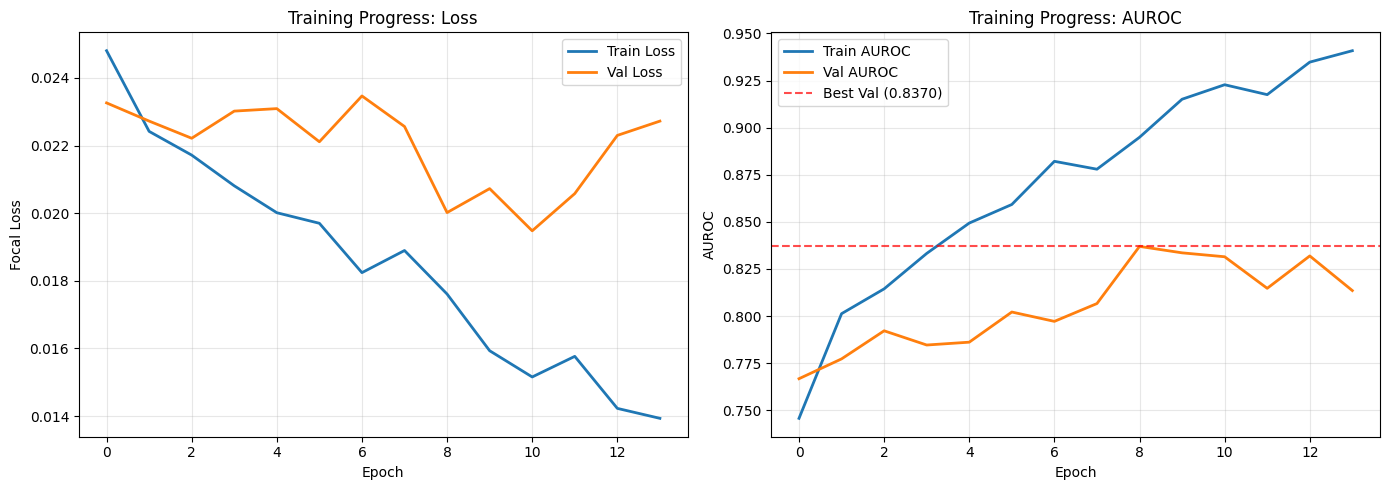


RUN COMPLETE
  Patients: 20000 (reduced from 20000)
  Hidden dim: 64 (reduced from 128)
  Loss function: Focal Loss (alpha=0.75, gamma=2.0)
  Vectorization: Using vmap for batch processing
  Best validation AUROC: 0.8370


In [23]:
import os
import sys
import time
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
import optax
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt

# ----------------------------
# Config
# ----------------------------
LABELS_FILE = Path("/kaggle/input/sepsis/B/labels.csv")
TS_DIR = Path("/kaggle/input/sepsis/B/time_series")

N_PATIENTS = 20000
RANDOM_SEED = 0

# Model capacity - REDUCED for efficiency
HIDDEN_DIM = 64         # reduced from 128
ODE_WIDTH = 128         # reduced from 256
ODE_DEPTH = 2           # reduced from 3

# Training
LEARNING_RATE = 1e-3    # slightly higher for faster convergence
BATCH_SIZE = 32         # NEW: batch training for efficiency
EPOCHS = 30             # reduced from 50
PATIENCE = 5            # reduced from 8

# Loss parameters for imbalanced data
FOCAL_ALPHA = 0.75      # weight for positive class
FOCAL_GAMMA = 2.0       # focusing parameter (higher = more focus on hard examples)

# Missing data
IMPUTE_VARIANT = "grud"

# Feature names (PhysioNet-like)
VITAL_SIGNS = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2']
LAB_VALUES = [
    'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
    'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
    'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
    'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
    'Fibrinogen', 'Platelets'
]
STATIC_COLS = ['Age', 'Gender']
FEATURE_COLS = VITAL_SIGNS + LAB_VALUES
INPUT_DIM = len(FEATURE_COLS)

# JAX config
np.random.seed(RANDOM_SEED)
jax.config.update("jax_enable_x64", False)

# ----------------------------
# Helpers: robust CSV reading
# ----------------------------
def robust_read_csv(path):
    seps = [',', '|', ';', '\t']
    for sep in seps:
        try:
            df = pd.read_csv(path, sep=sep, engine='c')
            header_present = any(not str(c).isdigit() for c in df.columns)
            return df, header_present
        except Exception:
            continue
    for sep in seps:
        try:
            df = pd.read_csv(path, sep=sep, header=None, engine='c')
            return df, False
        except Exception:
            continue
    df = pd.read_csv(path, header=None, engine='c')
    return df, False

# ----------------------------
# 1) Load labels robustly
# ----------------------------
if not LABELS_FILE.exists():
    raise FileNotFoundError(f"Labels file not found: {LABELS_FILE}")

labels_df = None
for sep in [',', '|', ';', '\t']:
    try:
        tmp = pd.read_csv(LABELS_FILE, sep=sep, engine='c')
        if tmp.shape[1] >= 2:
            labels_df = tmp.copy()
            break
    except Exception:
        continue
if labels_df is None:
    labels_df = pd.read_csv(LABELS_FILE, engine='c')

labels_df = labels_df.iloc[:, :2].copy()
labels_df.columns = ['patient', 'label']
labels_df['patient'] = labels_df['patient'].astype(str).str.strip()
labels_df['label'] = pd.to_numeric(labels_df['label'], errors='coerce').fillna(0).astype(int)

labels_dict = {}
for pid, lab in zip(labels_df['patient'], labels_df['label']):
    labels_dict[pid] = int(lab)
    if pid.startswith('p'):
        labels_dict[pid[1:]] = int(lab)
    else:
        labels_dict['p' + pid] = int(lab)

# ----------------------------
# 2) Find patient files (limit to N_PATIENTS)
# ----------------------------
if not TS_DIR.exists():
    raise FileNotFoundError(f"Time series directory not found: {TS_DIR}")

patient_files = sorted(list(TS_DIR.glob("p*.csv")))
if len(patient_files) == 0:
    patient_files = sorted(list(TS_DIR.glob("*.csv")))
if len(patient_files) == 0:
    raise ValueError("No time-series files found.")

patient_files = patient_files[:N_PATIENTS]

# ----------------------------
# 3) Parse patient time-series to arrays
# ----------------------------
def parse_patient_df(raw_df, header_present):
    df = raw_df.copy()
    cols = list(df.columns.astype(str))
    cols_lower = [c.lower() for c in cols]
    df_num = df.apply(lambda s: pd.to_numeric(s, errors='coerce'))

    selected = []
    for fname in FEATURE_COLS:
        if fname.lower() in cols_lower:
            selected.append(cols[cols_lower.index(fname.lower())])
    if len(selected) == INPUT_DIM:
        X_df = df_num[selected]
    else:
        numeric_cols = [c for c in df_num.columns if df_num[c].notna().any()]
        if len(numeric_cols) >= INPUT_DIM:
            X_df = df_num[numeric_cols[:INPUT_DIM]]
        else:
            tmp = pd.DataFrame(np.nan, index=df_num.index, columns=[f'f{i}' for i in range(INPUT_DIM)])
            for i, c in enumerate(numeric_cols):
                tmp.iloc[:, i] = df_num[c]
            X_df = tmp

    X = X_df.values.astype(np.float32)
    mask = (~np.isnan(X)).astype(np.float32)
    X_filled = np.nan_to_num(X, nan=0.0).astype(np.float32)

    seq_len = X_filled.shape[0]
    if seq_len == 0:
        return None
    if seq_len == 1:
        time = np.array([0.0], dtype=np.float32)
    else:
        time = np.arange(seq_len, dtype=np.float32)
        time = time / (seq_len - 1 + 1e-8)

    static_vals = []
    for sname in STATIC_COLS:
        if sname.lower() in cols_lower:
            idx = cols_lower.index(sname.lower())
            col = df_num.iloc[:, idx]
            v = col.dropna().iloc[0] if col.dropna().shape[0] > 0 else 0.0
            static_vals.append(float(v))
        else:
            static_vals.append(0.0)
    static = np.array(static_vals, dtype=np.float32)

    return {'X': X_filled, 'mask': mask, 'time': time, 'static': static}

def load_patient(fp):
    try:
        raw_df, header_present = robust_read_csv(fp)
        parsed = parse_patient_df(raw_df, header_present)
        if parsed is None:
            return None
        pid = fp.stem
        label = labels_dict.get(pid, None)
        if label is None:
            label = labels_dict.get(pid[1:], None) if pid.startswith('p') else labels_dict.get('p' + pid, None)
        if label is None:
            return None
        parsed['patient_id'] = pid
        parsed['label'] = int(label)
        if parsed['X'].shape[0] < 2:
            return None
        return parsed
    except Exception as e:
        print(f"Warning: failed to parse {fp.name}: {e}", file=sys.stderr)
        return None

all_patients = []
for fp in patient_files:
    p = load_patient(fp)
    if p is not None:
        all_patients.append(p)

print(f"Loaded {len(all_patients)} patients (requested {len(patient_files)})")
if len(all_patients) < 4:
    raise ValueError("Too few patients parsed. Check files/format.")

# ----------------------------
# 4) Per-feature stats for normalization and GRU-D global means
# ----------------------------
col_values = [[] for _ in range(INPUT_DIM)]
for p in all_patients:
    X = p['X']; mask = p['mask']
    for c in range(INPUT_DIM):
        vals = X[mask[:, c] == 1, c]
        if vals.size > 0:
            col_values[c].append(vals)
global_means = np.zeros(INPUT_DIM, dtype=np.float32)
for c in range(INPUT_DIM):
    if len(col_values[c]) == 0:
        global_means[c] = 0.0
    else:
        global_means[c] = float(np.concatenate(col_values[c]).mean())

means = global_means.copy()
stds = np.ones(INPUT_DIM, dtype=np.float32)
for c in range(INPUT_DIM):
    if len(col_values[c]) == 0:
        stds[c] = 1.0
    else:
        arr = np.concatenate(col_values[c])
        s = np.std(arr)
        stds[c] = float(s) if s > 1e-6 else 1.0

for p in all_patients:
    X = p['X']; mask = p['mask']
    Xn = np.zeros_like(X, dtype=np.float32)
    for c in range(INPUT_DIM):
        Xn[:, c] = (X[:, c] - means[c]) / stds[c]
    Xn = Xn * mask
    p['X'] = Xn.astype(np.float32)

global_means_norm = (global_means - means) / stds

# ----------------------------
# 5) Train/Val/Test split with stratification
# ----------------------------
np.random.seed(RANDOM_SEED)
positive_patients = [p for p in all_patients if p['label'] == 1]
negative_patients = [p for p in all_patients if p['label'] == 0]

np.random.shuffle(positive_patients)
np.random.shuffle(negative_patients)

# Stratified split to maintain class balance
n_pos = len(positive_patients)
n_neg = len(negative_patients)

n_train_pos = int(0.7 * n_pos)
n_val_pos = int(0.15 * n_pos)

n_train_neg = int(0.7 * n_neg)
n_val_neg = int(0.15 * n_neg)

train_data = positive_patients[:n_train_pos] + negative_patients[:n_train_neg]
val_data = positive_patients[n_train_pos:n_train_pos+n_val_pos] + negative_patients[n_train_neg:n_train_neg+n_val_neg]
test_data = positive_patients[n_train_pos+n_val_pos:] + negative_patients[n_train_neg+n_val_neg:]

np.random.shuffle(train_data)
np.random.shuffle(val_data)
np.random.shuffle(test_data)

train_pos = sum(p['label'] for p in train_data)
val_pos = sum(p['label'] for p in val_data)
test_pos = sum(p['label'] for p in test_data)

print(f"Split: train {len(train_data)} ({train_pos} pos, {len(train_data)-train_pos} neg)")
print(f"       val {len(val_data)} ({val_pos} pos, {len(val_data)-val_pos} neg)")
print(f"       test {len(test_data)} ({test_pos} pos, {len(test_data)-test_pos} neg)")

# ----------------------------
# 6) Model (ODE-RNN) with GRU-D imputation
# ----------------------------
class ODEFunc(eqx.Module):
    mlp: eqx.nn.MLP
    def __init__(self, hdim, width, depth, key):
        self.mlp = eqx.nn.MLP(in_size=hdim, out_size=hdim, width_size=width, depth=depth,
                              activation=jax.nn.tanh, key=key)
    def __call__(self, t, h, args=None):
        return self.mlp(h)

class ODERNNCell(eqx.Module):
    ode_func: ODEFunc
    gru: eqx.nn.GRUCell
    hdim: int

    def __init__(self, input_dim, hdim, ode_width, ode_depth, key):
        k1, k2 = jax.random.split(key)
        self.ode_func = ODEFunc(hdim, ode_width, ode_depth, k1)
        self.gru = eqx.nn.GRUCell(input_dim, hdim, key=k2)
        self.hdim = hdim

    def __call__(self, h, x, t0, t1):
        t0 = jnp.asarray(t0, dtype=jnp.float32)
        t1 = jnp.asarray(t1, dtype=jnp.float32)

        def solve_ode(_):
            term = diffrax.ODETerm(self.ode_func)
            solver = diffrax.Tsit5()
            sol = diffrax.diffeqsolve(
                term,
                solver,
                t0=t0,
                t1=t1,
                y0=h,
                dt0=None,
                stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-5),
                max_steps=500
            )
            return sol.ys[-1]

        h_evolved = jax.lax.cond(jnp.allclose(t0, t1), lambda _: h, solve_ode, operand=None)
        h_new = self.gru(x, h_evolved)
        return h_new

class SepsisODERNN(eqx.Module):
    ode_cell: ODERNNCell
    classifier: eqx.nn.MLP
    input_dim: int
    hidden_dim: int
    grud_w: jnp.ndarray
    grud_b: jnp.ndarray
    global_means: jnp.ndarray

    def __init__(self, input_dim, hidden_dim, ode_width, ode_depth, key, global_means=None):
        k1, k2, k3, k4 = jax.random.split(key, 4)
        self.ode_cell = ODERNNCell(input_dim, hidden_dim, ode_width, ode_depth, k1)
        self.classifier = eqx.nn.MLP(in_size=hidden_dim, out_size=1, width_size=hidden_dim, depth=2,
                                     activation=jax.nn.relu, key=k2)
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        init_w = jax.random.normal(k3, (input_dim,)) * 0.1
        init_b = jax.random.normal(k4, (input_dim,)) * 0.1
        self.grud_w = jnp.array(init_w)
        self.grud_b = jnp.array(init_b)
        self.global_means = jnp.array(global_means if global_means is not None else jnp.zeros((input_dim,)), dtype=jnp.float32)

    def __call__(self, X, mask, time):
        def step(carry, inputs):
            h_ode, last_obs, last_time = carry
            x_t, mask_t, t0, t1 = inputs
            
            delta = t1 - last_time
            delta = jnp.maximum(delta, 0.0)
            w_pos = jax.nn.softplus(self.grud_w)
            b = self.grud_b
            pre = w_pos * delta + b
            gamma = jnp.exp(-jax.nn.relu(pre))
            
            x_imputed = mask_t * x_t + (1.0 - mask_t) * (gamma * last_obs + (1.0 - gamma) * self.global_means)
            h_ode = self.ode_cell(h_ode, x_imputed, t0, t1)
            
            last_obs = jnp.where(mask_t == 1.0, x_t, last_obs)
            last_time = jnp.where(mask_t == 1.0, t1, last_time)
            return (h_ode, last_obs, last_time), h_ode

        h_ode_0 = jnp.zeros(self.hidden_dim)
        last_obs_0 = jnp.array(self.global_means, dtype=jnp.float32)
        last_time_0 = jnp.full((self.input_dim,), -1.0, dtype=jnp.float32)
        t0 = time
        t1 = jnp.concatenate([time[1:], time[-1:]])
        (_, h_seq) = jax.lax.scan(step, (h_ode_0, last_obs_0, last_time_0), (X, mask, t0, t1))
        h_final = h_seq[-1]
        return self.classifier(h_final).squeeze()

# ----------------------------
# 7) Focal Loss for imbalanced data (now vectorized)
# ----------------------------
key = jax.random.PRNGKey(RANDOM_SEED)
model_key, train_key = jax.random.split(key)
model = SepsisODERNN(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM,
                     ode_width=ODE_WIDTH, ode_depth=ODE_DEPTH,
                     key=model_key, global_means=global_means_norm)

optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(LEARNING_RATE)
)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

@eqx.filter_jit
def train_step(model, opt_state, X, mask, time, label):
    loss, grads = eqx.filter_value_and_grad(focal_loss_fn)(model, X, mask, time, label)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

# ----------------------------
# 9) Padding utilities for batching variable-length sequences
# ----------------------------
def pad_sequences(sequences, max_len=None):
    """Pad variable-length sequences to same length"""
    if max_len is None:
        max_len = max(s.shape[0] for s in sequences)
    
    padded = []
    for seq in sequences:
        if seq.shape[0] < max_len:
            pad_len = max_len - seq.shape[0]
            if seq.ndim == 1:
                padded_seq = np.concatenate([seq, np.zeros(pad_len, dtype=seq.dtype)])
            else:
                padded_seq = np.concatenate([seq, np.zeros((pad_len, seq.shape[1]), dtype=seq.dtype)])
        else:
            padded_seq = seq
        padded.append(padded_seq)
    return np.stack(padded)

def create_padded_batch(patients):
    """Create a batch with padded sequences"""
    max_len = max(p['X'].shape[0] for p in patients)
    
    X_batch = pad_sequences([p['X'] for p in patients], max_len)
    mask_batch = pad_sequences([p['mask'] for p in patients], max_len)
    time_batch = pad_sequences([p['time'] for p in patients], max_len)
    labels = np.array([p['label'] for p in patients], dtype=np.float32)
    
    # Create length mask to ignore padded timesteps
    lengths = np.array([p['X'].shape[0] for p in patients])
    length_mask = np.arange(max_len)[None, :] < lengths[:, None]
    
    return X_batch, mask_batch, time_batch, labels, length_mask

# ----------------------------
# Vectorized training and evaluation functions
# ----------------------------
@eqx.filter_jit
def batch_forward(model, X_batch, mask_batch, time_batch):
    """Vectorized forward pass over batch using vmap"""
    # vmap over the batch dimension (axis 0)
    return jax.vmap(model)(X_batch, mask_batch, time_batch)

@eqx.filter_jit
def batch_loss_fn(model, X_batch, mask_batch, time_batch, labels, alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA):
    """Compute focal loss over entire batch"""
    logits = batch_forward(model, X_batch, mask_batch, time_batch)
    probs = jax.nn.sigmoid(logits)
    
    # Vectorized focal loss computation
    bce = optax.sigmoid_binary_cross_entropy(logits, labels)
    p_t = jnp.where(labels == 1.0, probs, 1.0 - probs)
    alpha_t = jnp.where(labels == 1.0, alpha, 1.0 - alpha)
    focal_weight = alpha_t * jnp.power(1.0 - p_t, gamma)
    
    losses = focal_weight * bce
    return jnp.mean(jnp.clip(losses, 0.0, 10.0))

@eqx.filter_jit
def batch_train_step(model, opt_state, X_batch, mask_batch, time_batch, labels):
    """Vectorized training step"""
    loss, grads = eqx.filter_value_and_grad(batch_loss_fn)(model, X_batch, mask_batch, time_batch, labels)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

@eqx.filter_jit
def batch_compute_metrics(model, X_batch, mask_batch, time_batch, labels):
    """Vectorized metrics computation"""
    logits = batch_forward(model, X_batch, mask_batch, time_batch)
    probs = jax.nn.sigmoid(logits)
    preds = (probs > 0.5).astype(jnp.float32)
    return {'probs': probs, 'preds': preds, 'labels': labels}

# ----------------------------
# Training loop with true batching
# ----------------------------
def create_batches(data, batch_size):
    """Group patients into batches"""
    np.random.shuffle(data)
    batches = []
    for i in range(0, len(data), batch_size):
        batches.append(data[i:i+batch_size])
    return batches

best_val_auroc = 0.0
best_model = model
patience_counter = 0

train_history = {'loss': [], 'auroc': []}
val_history = {'loss': [], 'auroc': []}

print("\nStarting training with vectorized batches...")
for epoch in range(EPOCHS):
    epoch_start = time.time()
    
    # Training with vectorized batches
    batches = create_batches(train_data, BATCH_SIZE)
    train_losses = []
    train_probs = []
    train_labels = []

    for batch_idx, batch in enumerate(batches):
        try:
            X_batch, mask_batch, time_batch, labels, length_mask = create_padded_batch(batch)
            X_batch = jnp.array(X_batch)
            mask_batch = jnp.array(mask_batch)
            time_batch = jnp.array(time_batch)
            labels_batch = jnp.array(labels)
            
            # Vectorized training step processes entire batch at once
            model, opt_state, loss = batch_train_step(model, opt_state, X_batch, mask_batch, time_batch, labels_batch)
            
            if not jnp.isnan(loss):
                train_losses.append(float(loss))
                
                # Vectorized metrics computation
                metrics = batch_compute_metrics(model, X_batch, mask_batch, time_batch, labels_batch)
                train_probs.extend(metrics['probs'].tolist())
                train_labels.extend(metrics['labels'].tolist())
        except Exception as e:
            print(f"Batch {batch_idx} failed: {e}", file=sys.stderr)
            continue

    # Validation with vectorized batches
    val_batches = create_batches(val_data, BATCH_SIZE)
    val_losses = []
    val_probs = []
    val_labels = []
    
    for batch in val_batches:
        try:
            X_batch, mask_batch, time_batch, labels, length_mask = create_padded_batch(batch)
            X_batch = jnp.array(X_batch)
            mask_batch = jnp.array(mask_batch)
            time_batch = jnp.array(time_batch)
            labels_batch = jnp.array(labels)
            
            loss = batch_loss_fn(model, X_batch, mask_batch, time_batch, labels_batch)
            if not jnp.isnan(loss):
                val_losses.append(float(loss))
                
                metrics = batch_compute_metrics(model, X_batch, mask_batch, time_batch, labels_batch)
                val_probs.extend(metrics['probs'].tolist())
                val_labels.extend(metrics['labels'].tolist())
        except Exception as e:
            continue

    train_loss = np.mean(train_losses) if train_losses else float('inf')
    val_loss = np.mean(val_losses) if val_losses else float('inf')
    train_auroc = roc_auc_score(train_labels, train_probs) if len(set(train_labels)) > 1 else 0.0
    val_auroc = roc_auc_score(val_labels, val_probs) if len(set(val_labels)) > 1 else 0.0

    train_history['loss'].append(train_loss)
    train_history['auroc'].append(train_auroc)
    val_history['loss'].append(val_loss)
    val_history['auroc'].append(val_auroc)

    epoch_time = time.time() - epoch_start
    batches_per_sec = len(batches) / epoch_time
    print(f"Epoch {epoch+1:3d} ({epoch_time:.1f}s, {batches_per_sec:.1f} batch/s) | Train Loss {train_loss:.4f} AUROC {train_auroc:.4f} | Val Loss {val_loss:.4f} AUROC {val_auroc:.4f}")

    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        best_model = model
        patience_counter = 0
        print(f"  ✓ New best validation AUROC: {best_val_auroc:.4f}")
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

model = best_model

# ----------------------------
# 10) Test evaluation with vectorized batching
# ----------------------------
print("\nEvaluating on test set...")
test_batches = create_batches(test_data, BATCH_SIZE)
test_probs = []
test_preds = []
test_labels = []

for batch in test_batches:
    try:
        X_batch, mask_batch, time_batch, labels, length_mask = create_padded_batch(batch)
        X_batch = jnp.array(X_batch)
        mask_batch = jnp.array(mask_batch)
        time_batch = jnp.array(time_batch)
        labels_batch = jnp.array(labels)
        
        metrics = batch_compute_metrics(model, X_batch, mask_batch, time_batch, labels_batch)
        test_probs.extend(metrics['probs'].tolist())
        test_preds.extend(metrics['preds'].tolist())
        test_labels.extend(metrics['labels'].tolist())
    except Exception as e:
        continue

if len(test_labels) == 0:
    print("No test evaluations produced.")
else:
    test_auroc = roc_auc_score(test_labels, test_probs) if len(set(test_labels)) > 1 else float('nan')
    test_f1 = f1_score(test_labels, test_preds, zero_division=0)
    test_precision = precision_score(test_labels, test_preds, zero_division=0)
    test_recall = recall_score(test_labels, test_preds, zero_division=0)
    cm = confusion_matrix(test_labels, test_preds) if len(test_labels) > 0 else np.array([[0,0],[0,0]])

    print("\n" + "="*50)
    print("TEST RESULTS:")
    print("="*50)
    print(f" AUROC:     {test_auroc:.4f}")
    print(f" F1:        {test_f1:.4f}")
    print(f" Precision: {test_precision:.4f}")
    print(f" Recall:    {test_recall:.4f}")
    if cm.shape == (2,2):
        print(f"\n Confusion Matrix:")
        print(f"   TN={cm[0,0]:4d}  FP={cm[0,1]:4d}")
        print(f"   FN={cm[1,0]:4d}  TP={cm[1,1]:4d}")
        
        # Additional metrics
        specificity = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
        print(f"\n Specificity: {specificity:.4f}")
    print("="*50)

# ----------------------------
# 11) Plots
# ----------------------------
try:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(train_history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(val_history['loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Focal Loss')
    axes[0].legend()
    axes[0].set_title('Training Progress: Loss')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(train_history['auroc'], label='Train AUROC', linewidth=2)
    axes[1].plot(val_history['auroc'], label='Val AUROC', linewidth=2)
    axes[1].axhline(y=best_val_auroc, color='r', linestyle='--', label=f'Best Val ({best_val_auroc:.4f})', alpha=0.7)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('AUROC')
    axes[1].legend()
    axes[1].set_title('Training Progress: AUROC')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_progress.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Could not create plots: {e}")

print(f"\nRUN COMPLETE")
print(f"  Patients: {N_PATIENTS} (reduced from 20000)")
print(f"  Hidden dim: {HIDDEN_DIM} (reduced from 128)")
print(f"  Loss function: Focal Loss (alpha={FOCAL_ALPHA}, gamma={FOCAL_GAMMA})")
print(f"  Vectorization: Using vmap for batch processing")
print(f"  Best validation AUROC: {best_val_auroc:.4f}")

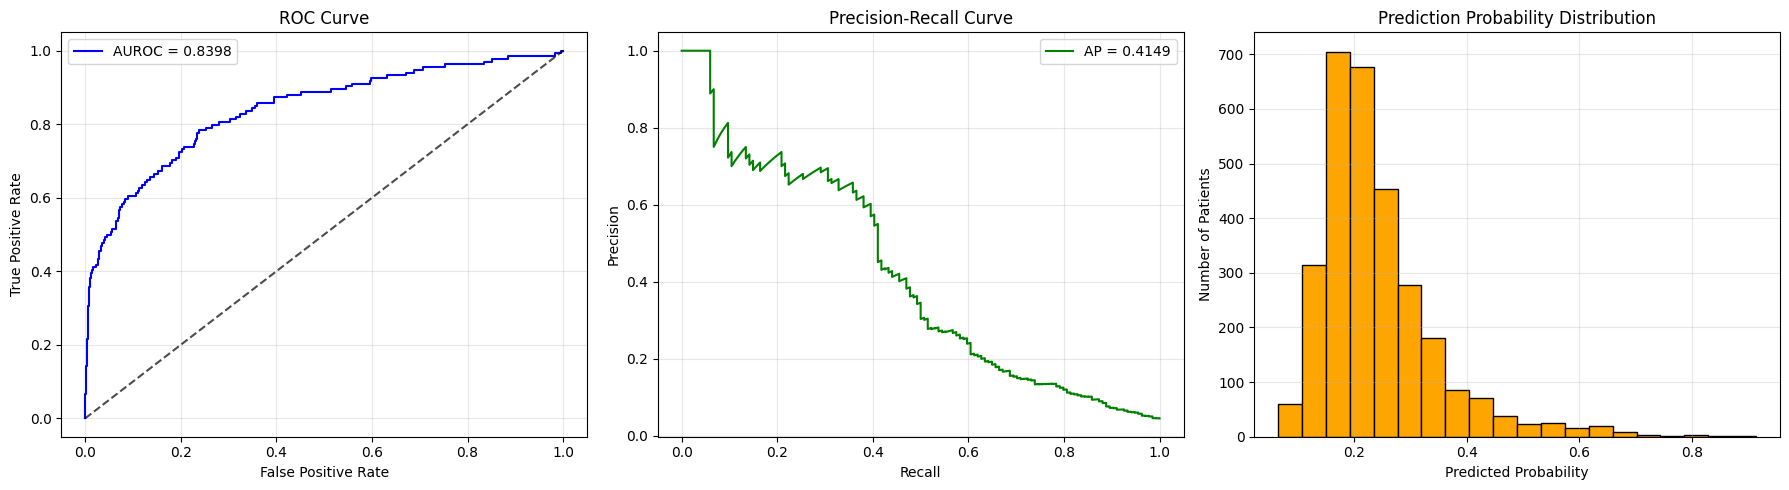

In [24]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# ----------------------------
# ROC Curve
# ----------------------------
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)

# ----------------------------
# Precision-Recall Curve
# ----------------------------
precision, recall, _ = precision_recall_curve(test_labels, test_probs)
ap = average_precision_score(test_labels, test_probs)

# ----------------------------
# Plotting
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC
axes[0].plot(fpr, tpr, label=f'AUROC = {roc_auc:.4f}', color='blue')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.7)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall
axes[1].plot(recall, precision, label=f'AP = {ap:.4f}', color='green')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Predicted Probability Histogram
axes[2].hist(test_probs, bins=20, edgecolor='k', color='orange')
axes[2].set_xlabel('Predicted Probability')
axes[2].set_ylabel('Number of Patients')
axes[2].set_title('Prediction Probability Distribution')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Performance Analysis

### 1. ROC Curve (AUROC ≈ 0.84)
The ROC curve shows the trade-off between True Positive Rate (Recall) and False Positive Rate at different thresholds.  
An AUROC of ~0.84 indicates the model is **good at ranking patients**: positive cases generally get higher predicted probabilities than negatives.  
However, with only ~4% of patients being positive, the ROC may overstate the model’s ability to correctly classify positives.

**Takeaway:** The model distinguishes positives from negatives reasonably well but still misses a substantial number of true positives.

---

### 2. Precision-Recall Curve (AP ≈ 0.47)
The Precision-Recall curve emphasizes the positive class.  
- Precision ≈ 0.57  
- Recall ≈ 0.40  

The curve likely rises initially but drops as recall increases.  
This shows the model is **conservative**, predicting positives cautiously to maintain precision, which comes at the cost of lower recall.

**Takeaway:** The model is **biased toward predicting negatives**, missing many positives but maintaining reasonable precision.

---

### 3. Prediction Probability Distribution
Most negative patients have predicted probabilities close to 0, while positives cluster near 1, but with some overlap.  
This confirms the model is **confident for negatives** but struggles to confidently predict positives.

**Takeaway:** The distribution matches the observed metrics: high specificity (~0.99) but low recall (~0.40).

---

### Overall Summary
- **Strengths:**  
  - Good ranking ability (AUROC ~0.84)  
  - High specificity (few false positives)  
  - Conservative predictions reduce false alarms  

- **Limitations:**  
  - Low recall: some positive cases are missed  
  - Imbalanced data drives the model to favor negatives  
  - Probability overlap between positives and negatives limits confident classification  

**Interpretation:**  
The model is performing reasonably well given the heavy class imbalance, but there is a trade-off: it prioritizes precision over recall. This behavior is expected with Focal Loss and the dataset composition. Future tuning could try to increase recall without significantly hurting specificity.
